In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드 및 전처리 (노원구 제외 버전)

In [2]:
# 데이터 로드
clean_path = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/processed_office_data.csv"
df = pd.read_csv(clean_path)

print(f"원본 데이터 크기: {len(df)}행")

# 총매물수 컬럼 생성 (거래완료 + 등록매물)
if "총매물수" not in df.columns:
    df["총매물수"] = df["거래완료"] + df["등록매물"]
    
print(f"컬럼 목록: {df.columns.tolist()}")

원본 데이터 크기: 356행
컬럼 목록: ['등록번호', '중개사명', '대표자', '전화번호', '주소', '거래완료', '등록매물', '개설시작일', '개설종료일', '등록일', '상태구분코드', '상태구분명', '지역코드', '지역명', '도로명주소코드', '최종수정일', '총_직원수', '공인중개사수', '중개보조원수', '대표수', '일반직원수', '직원목록_JSON', '직원명단', '총매물수']


In [3]:
# --------------------------------------------------------------------------------
# 1. 특이값(Outlier) 제거: 노원구
# --------------------------------------------------------------------------------
outlier_region = "서울특별시 노원구"
df = df[df["지역명"] != outlier_region].copy()

print(f"✅ '{outlier_region}' 제거 후 데이터 크기: {len(df)}행")

✅ '서울특별시 노원구' 제거 후 데이터 크기: 355행


In [4]:
# --------------------------------------------------------------------------------
# 2. 표본이 적은 지역 제거 (총매물수 500건 미만)
# --------------------------------------------------------------------------------
threshold_cnt = 500

# 지역별 총매물수 집계
region_counts = df.groupby("지역명")["총매물수"].sum()

# 기준 미만인 지역명 찾기
small_regions = region_counts[region_counts < threshold_cnt].index

# 데이터프레임 필터링
df_filtered = df[~df["지역명"].isin(small_regions)].copy()

print(f"🔍 기준({threshold_cnt}건) 미만 지역 수: {len(small_regions)}개")
print(f"   (제외 목록: {list(small_regions)})")
print(f"✅ 필터링 후 데이터 크기: {len(df_filtered)}행")

# df 업데이트
df = df_filtered

🔍 기준(500건) 미만 지역 수: 5개
   (제외 목록: ['서울특별시 도봉구', '서울특별시 성동구', '서울특별시 성북구', '서울특별시 종로구', '서울특별시 중구'])
✅ 필터링 후 데이터 크기: 339행


지역별 통계 (노원구 제외, 소규모 지역 제외):


,mean,std,count,mean_ratio(%),std_ratio(%)
지역명,,,,,
서울특별시 강북구,0.732385,0.243030,6,73.238511,24.303023
서울특별시 은평구,0.685061,0.283754,10,68.506092,28.375437
서울특별시 마포구,0.631434,0.260716,13,63.143419,26.071640
서울특별시 용산구,0.629712,0.352807,17,62.971234,35.280729
서울특별시 송파구,0.616950,0.291581,18,61.694989,29.158079
서울특별시 광진구,0.616149,0.322018,24,61.614921,32.201838
서울특별시 영등포구,0.608095,0.349656,15,60.809481,34.965568
서울특별시 동작구,0.569581,0.275859,14,56.958077,27.585868
서울특별시 서대문구,0.565002,0.406440,6,56.500201,40.644000


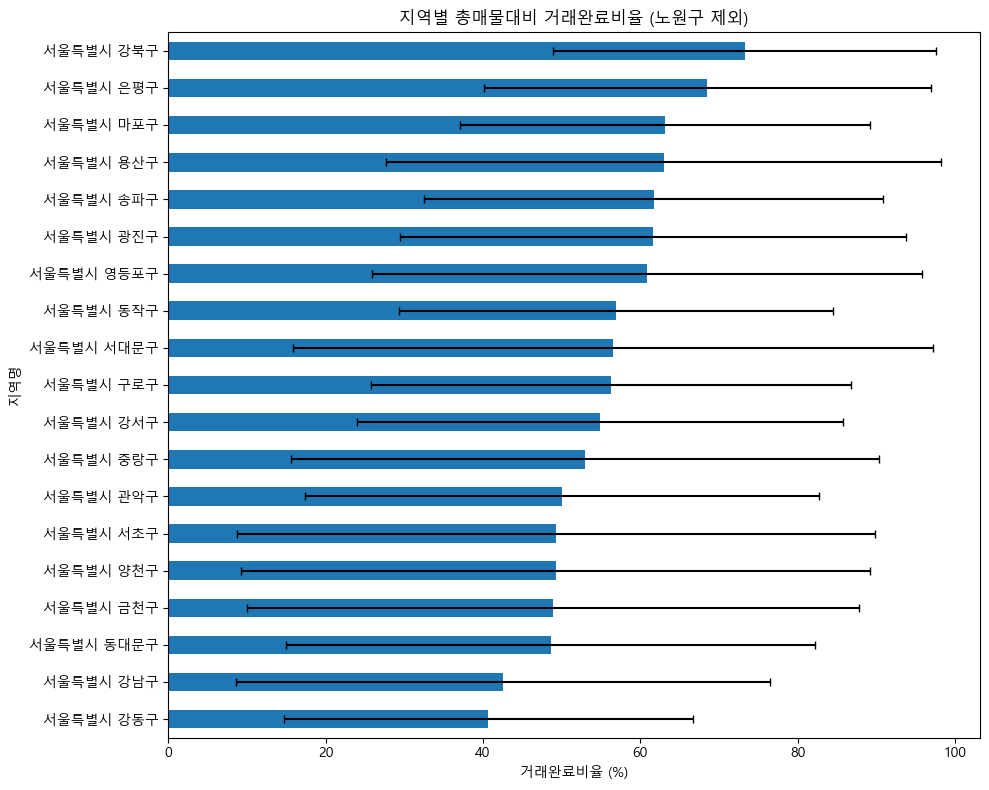

In [ ]:
# --------------------------------------------------------------------------------
# 3. 지역별 통계 (평균, 표준편차) 계산 및 시각화
# --------------------------------------------------------------------------------
# 중개사별 거래완료비율 계산
df["거래완료비율"] = df["거래완료"] / df["총매물수"]

# 지역별 집계 (평균, 표준편차, 개수)
region_stats = df.groupby("지역명")["거래완료비율"].agg(["mean", "std", "count"])

# 표준편차 결측치(NaN) 처리: 0으로 대체 (표본 1개인 경우)
# 표본이 1개라 편차가 없는 것이므로 0은 타당한 수치
region_stats["std"] = region_stats["std"].fillna(0)

# % 변환
region_stats["mean_ratio(%)"] = region_stats["mean"] * 100
region_stats["std_ratio(%)"] = region_stats["std"] * 100

print("지역별 통계 (노원구 제외, 소규모 지역 제외):")
display(region_stats.sort_values("mean", ascending=False))

# 시각화
plt.figure(figsize=(10, 8))
region_stats["mean_ratio(%)"].sort_values().plot(
    kind="barh", 
    xerr=region_stats["std_ratio(%)"], 
    capsize=3
)
plt.title("지역별 총매물대비 거래완료비율 (노원구 제외)")
plt.xlabel("거래완료비율 (%)")
plt.tight_layout()
plt.show()